In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

with open("../data/RML2016.10a_dict.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))

C:\Users\lnloh\AppData\Local\Temp\ipykernel_8780\3566086470.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


<class 'dict'>


In [3]:
keys = list(data.keys())

mods = sorted(set(mod for mod, snr in keys))
snrs = sorted(set(snr for mod, snr in keys))

print(f"Total keys: {len(keys)}")
print(f"Modulations: {mods}")
print(f"SNRs: {snrs}")

Total keys: 220
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNRs: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [4]:
sample_key = ("BPSK", 18)
array = data[sample_key]
print(f"Shape of the array for key {sample_key}: {array.shape}")
print(f"Single sample shape: {array[0].shape}")
print(f"Data type of the array: {array.dtype}")

Shape of the array for key ('BPSK', 18): (1000, 2, 128)
Single sample shape: (2, 128)
Data type of the array: float32


In [5]:
sample = data[("BPSK", 18)][0]

print(f"I channel (first 10 values ):\n{sample[0][:10]}")
print(f"Q channel (first 10 values ):\n{sample[1][:10]}")

print(f"\n I min: {sample[0].min():.4f}, I max: {sample[0].max():.4f}")
print(f" Q min: {sample[1].min():.4f}, Q max: {sample[1].max():.4f}")

I channel (first 10 values ):
[-3.1633020e-04  6.6836037e-05 -7.6790003e-04 -5.7558407e-04
 -5.5835804e-04  1.4250478e-04  2.3223397e-04  4.7186663e-04
 -2.0780989e-04  5.0438923e-04]
Q channel (first 10 values ):
[ 0.00014015 -0.00019198 -0.00037653 -0.00032971 -0.0004105   0.00055068
  0.00106949 -0.00040754  0.00066566  0.00014849]

 I min: -0.0177, I max: 0.0129
 Q min: -0.0631, Q max: 0.0705


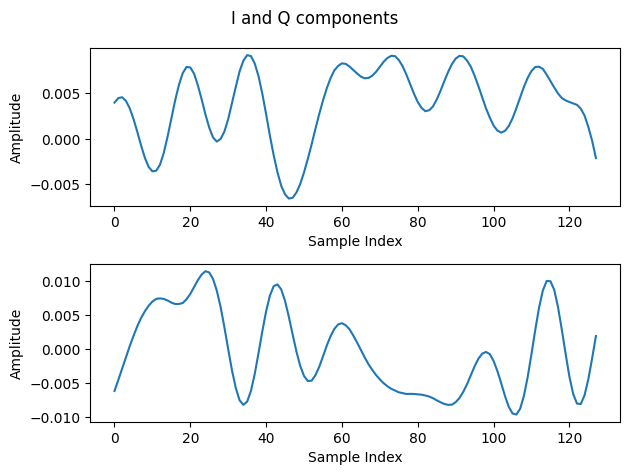

In [6]:
sample_key = ("QAM16", 18)
test = data[sample_key][0]


def plot_iq(sample):
    i_row = sample[0, :]
    q_row = sample[1, :]
    x = range(len(i_row))
    fig, axs = plt.subplots(2)
    plt.suptitle("I and Q components")
    axs[0].plot(x, i_row)
    axs[0].set_xlabel("Sample Index")
    axs[0].set_ylabel("Amplitude")
    axs[1].plot(x, q_row)
    axs[1].set_xlabel("Sample Index")
    axs[1].set_ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


plot_iq(test)

In [10]:
sample_key = ("QAM16", 18)
exp = data[sample_key][0]


def extract_features(sample):
    i_row = sample[0, :]
    q_row = sample[1, :]
    amplitude = np.sqrt(i_row**2 + q_row**2)
    amp_mean = np.mean(amplitude)
    amp_std = np.std(amplitude)
    # Calculate skew and kurtosis of amplitude
    amp_skew = stats.skew(amplitude)
    amp_kurt = stats.kurtosis(amplitude)
    # Compute unwrapped phase
    phase = np.arctan2(q_row, i_row)
    unwrapped_phase = np.unwrap(phase)
    # Calculate phase mean and standard deviation
    phase_mean = np.mean(unwrapped_phase)
    phase_std = np.std(unwrapped_phase)
    # Differentiate the unwrapped phase to get instantaneous frequency
    inst_freq = np.diff(unwrapped_phase)
    inst_freq_mean = np.mean(inst_freq)
    inst_freq_std = np.std(inst_freq)
    # FFT of complex signal
    complex_signal = i_row + 1j * q_row
    fft_result = np.fft.fft(complex_signal)
    fft_power = np.abs(fft_result) ** 2
    fft_mean = np.mean(fft_power)
    fft_std = np.std(fft_power)
    fft_skew = stats.skew(fft_power)
    fft_kurt = stats.kurtosis(fft_power)
    features = [
        amp_mean,
        amp_std,
        amp_skew,
        amp_kurt,
        phase_mean,
        phase_std,
        inst_freq_mean,
        inst_freq_std,
        fft_mean,
        fft_std,
        fft_skew,
        fft_kurt,
    ]
    return np.array(features)


features = extract_features(exp)
print("Extracted features:")
for i, feat in enumerate(features):
    print(f"Feature {i+1}: {feat:.4f}")
print(f"Output shape : {features.shape}")
print(f"Output data type: {features.dtype}")

Extracted features:
Feature 1: 0.0078
Feature 2: 0.0026
Feature 3: -0.3565
Feature 4: -0.6202
Feature 5: 3.8638
Feature 6: 2.4763
Feature 7: 0.0269
Feature 8: 0.3340
Feature 9: 0.0087
Feature 10: 0.0356
Feature 11: 5.1847
Feature 12: 27.8772
Output shape : (12,)
Output data type: float32


In [13]:
from tqdm import tqdm

# Extract features on the entire dataset and create a feature matrix and label vector

feature_list = []
label_list = []

for (modulation, snr), samples in tqdm(data.items(), desc="Processing samples"):
    for sample in samples:
        features = extract_features(sample)
        feature_list.append(features)
        label_list.append(modulation)

# Convert lists to numpy arrays
X = np.array(feature_list)
y = np.array(label_list)
print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

Processing samples: 100%|██████████| 220/220 [14:16<00:00,  3.89s/it]

Feature matrix shape: (220000, 12)
Label vector shape: (220000,)


In [14]:
# Train Random Classifier model
# Stratified split to maintain class distribution in train and test sets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


def train_classifier(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    # Fit and evaluate the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")
    # Predict on test set
    y_pred = model.predict(X_test)

    return X_test, y_test, model, y_pred

In [15]:
X_test, y_test, model, y_pred = train_classifier(X, y)

Random Forest Classifier Accuracy: 0.4816


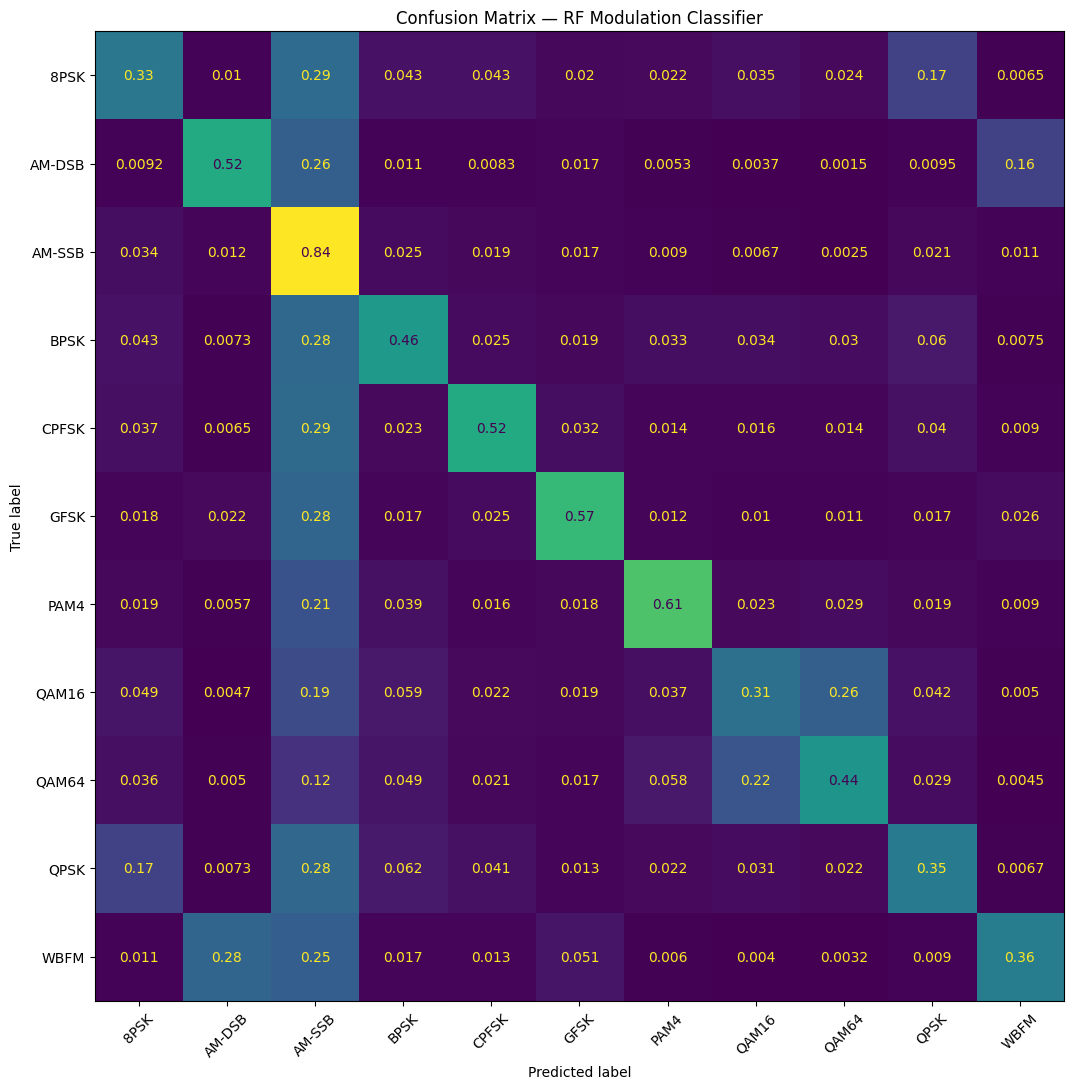

In [22]:
# plot confusion matrix, figure size 11 x 11 and save as png file
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=model.classes_, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(11, 11))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix — RF Modulation Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()